In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator




In [2]:
train_dir = r'C:\Users\Sakshi Bari\Documents\project\project\training'  # Correct train directory path
test_dir = r'C:\Users\Sakshi Bari\Documents\project\project\testing' 

In [3]:
# Load dataset in grayscale and rescale pixel values
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)



In [4]:
# Data augmentation and generators for grayscale images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    color_mode='grayscale',  # Convert images to grayscale
    batch_size=32,
    class_mode='categorical'  # One-hot encoding
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    color_mode='grayscale',  # Convert images to grayscale
    batch_size=32,
    class_mode='categorical',  # One-hot encoding
    shuffle=False  # Important to keep the order for confusion matrix
)

Found 1289 images belonging to 3 classes.
Found 12 images belonging to 3 classes.


In [5]:
# Define the CNN model for grayscale images
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),  # Updated input shape for grayscale
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes for Healthy, Sigatoka, and Xanthomonas
])

c:\Users\Sakshi Bari\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [7]:


`````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````# Train the model and store the history
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),  # Total number of batches
    epochs=25,
    validation_data=test_generator,
    validation_steps=len(test_generator)  # Total number of validation batches
)

c:\Users\Sakshi Bari\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 36s 754ms/step - accuracy: 0.5755 - loss: 1.2123 - val_accuracy: 0.2500 - val_loss: 1.8018
Epoch 2/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 597ms/step - accuracy: 0.6721 - loss: 0.8182 - val_accuracy: 0.3333 - val_loss: 1.6024
Epoch 3/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 588ms/step - accuracy: 0.6830 - loss: 0.7493 - val_accuracy: 0.4167 - val_loss: 1.1939
Epoch 4/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 592ms/step - accuracy: 0.7409 - loss: 0.6541 - val_accuracy: 0.5000 - val_loss: 1.2305
Epoch 5/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 590ms/step - accuracy: 0.8106 - loss: 0.5072 - val_accuracy: 0.5000 - val_loss: 1.0084
Epoch 6/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 593ms/step - accuracy: 0.8430 - loss: 0.4008 - val_accuracy: 0.6667 - val_loss: 0.8919
Epoch 7/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 613ms/step - accuracy: 0.9037 - loss: 0.2612 - val_accuracy: 0.8333 - val_loss: 0.6553
Epoch 8/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 616ms/step - accuracy: 0.9547 - loss: 0.1412 - val_accu

In [8]:
# Save the model
model.save("banana_Leaf_disease_model.h5")

In [9]:
# Generate predictions on the test set
test_generator.reset()  # Reset the generator to ensure no shuffling issues
predictions = model.predict(test_generator, steps=len(test_generator))
predicted_labels = np.argmax(predictions, axis=1)  # Get the index of the highest probability for each prediction
test_labels = test_generator.classes  # True labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


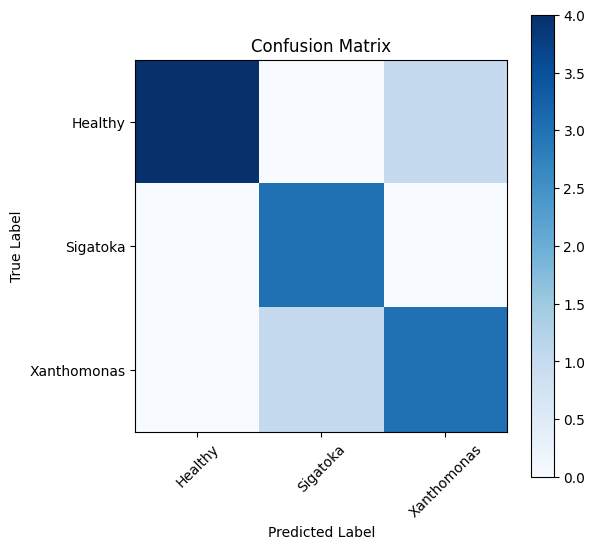

In [10]:
# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(3)
plt.xticks(tick_marks, ['Healthy', 'Sigatoka', 'Xanthomonas'], rotation=45)
plt.yticks(tick_marks, ['Healthy', 'Sigatoka', 'Xanthomonas'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

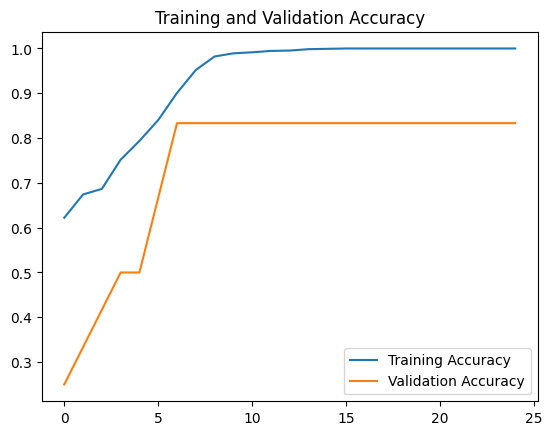

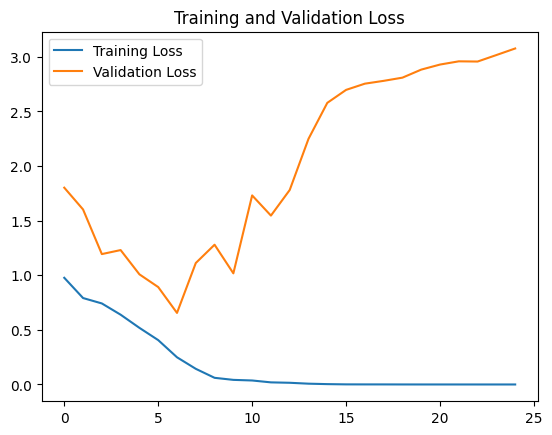

In [11]:
# Plot the accuracy and loss over epochs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [13]:
# Load and predict on a single test image
test_image = tf.keras.preprocessing.image.load_img(
    r'C:\Users\Sakshi Bari\Documents\project\project\testing\xanthamonas\img02.jpg',
    target_size=(224, 224),
    color_mode='grayscale'  # Convert to grayscale
)

In [14]:
# Convert the image to an array and rescale
test_image = tf.keras.preprocessing.image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)  # Expand dimensions to match the input shape of the model (1, 224, 224, 1)

In [15]:
# Predict using the trained model
result = model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


In [16]:
# Interpret the prediction
class_names = ['Healthy', 'Sigatoka', 'Xanthomonas']
predicted_class_index = np.argmax(result, axis=1)  # Get the index of the class with the highest probability
prediction = class_names[predicted_class_index[0]]  # Get the predicted class name

print('The test image is a', prediction, 'leaf.')

The test image is a Sigatoka leaf.


In [17]:
# Load the saved model to verify
loaded_model = tf.keras.models.load_model("banana_Leaf_disease_model.h5")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,773 (42.61 MB)

 Trainable params: 11,168,771 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [19]:
# Load and predict on a single test image
test_image = tf.keras.preprocessing.image.load_img(
    r'C:\Users\Sakshi Bari\Documents\project\project\testing\segatoka\img09.jpg',
    target_size=(224, 224),
    color_mode='grayscale'  # Convert to grayscale
)



In [19]:
# Convert the image to an array and rescale
test_image = tf.keras.preprocessing.image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)  # Expand dimensions to match the input shape of the model (1, 224, 224, 1)



In [20]:
# Predict using the trained model
result = model.predict(test_image)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [20]:
# Interpret the prediction
class_names = ['Healthy', 'Sigatoka', 'Xanthomonas']
predicted_class_index = np.argmax(result, axis=1)  # Get the index of the class with the highest probability
prediction = class_names[predicted_class_index[0]]  # Get the predicted class name

print('The test image is a', prediction, 'leaf.')



The test image is a Sigatoka leaf.


In [21]:
# Load the saved model to verify
loaded_model = tf.keras.models.load_model("banana_Leaf_disease_model.h5")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,773 (42.61 MB)

 Trainable params: 11,168,771 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [46]:
# Load and predict on a single test image
test_image = tf.keras.preprocessing.image.load_img(
    r'C:\Users\Sakshi Bari\Documents\project\project\testing\healthy\img12.jpg',
    target_size=(224, 224),
    color_mode='grayscale'  # Convert to grayscale
)
# Convert the image to an array and rescale
test_image = tf.keras.preprocessing.image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)  # Expand dimensions to match the input shape of the model (1, 224, 224, 1)
# Predict using the trained model
result = model.predict(test_image)
# Interpret the prediction
class_names = ['Healthy', 'Sigatoka', 'Xanthomonas']
predicted_class_index = np.argmax(result, axis=1)  # Get the index of the class with the highest probability
prediction = class_names[predicted_class_index[0]]  # Get the predicted class name

print('The test image is a', prediction, 'leaf.')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
The test image is a Healthy leaf.


In [40]:
# Load and predict on a single test image
test_image = tf.keras.preprocessing.image.load_img(
    r'C:\Users\Sakshi Bari\Documents\project\project\testing\segatoka\img11.jpg',
    target_size=(224, 224),
    color_mode='grayscale'  # Convert to grayscale
)
# Convert the image to an array and rescale
test_image = tf.keras.preprocessing.image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)  # Expand dimensions to match the input shape of the model (1, 224, 224, 1)
# Predict using the trained model
result = model.predict(test_image)
# Interpret the prediction
class_names = ['Healthy', 'Sigatoka', 'Xanthomonas']
predicted_class_index = np.argmax(result, axis=1)  # Get the index of the class with the highest probability
prediction = class_names[predicted_class_index[0]]  # Get the predicted class name

print('The test image is a', prediction, 'leaf.')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
The test image is a Sigatoka leaf.


In [47]:
# Load and predict on a single test image
test_image = tf.keras.preprocessing.image.load_img(
    r'C:\Users\Sakshi Bari\Documents\project\project\testing\xanthamonas\img01.jpg',
    target_size=(224, 224),
    color_mode='grayscale'  # Convert to grayscale
)
# Convert the image to an array and rescale
test_image = tf.keras.preprocessing.image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)  # Expand dimensions to match the input shape of the model (1, 224, 224, 1)
# Predict using the trained model
result = model.predict(test_image)
# Interpret the prediction
class_names = ['Healthy', 'Sigatoka', 'Xanthomonas']
predicted_class_index = np.argmax(result, axis=1)  # Get the index of the class with the highest probability
prediction = class_names[predicted_class_index[0]]  # Get the predicted class name

print('The test image is a', prediction, 'leaf.')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
The test image is a Xanthomonas leaf.
